<a href="https://colab.research.google.com/github/amithgoud/first-project/blob/main/california_linear_reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [211]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [212]:
url = "https://raw.githubusercontent.com/akmand/datasets/main/california_housing.csv"
df = pd.read_csv(url)
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                  41          880           129.0   
1    -122.22     37.86                  21         7099          1106.0   
2    -122.24     37.85                  52         1467           190.0   
3    -122.25     37.85                  52         1274           235.0   
4    -122.25     37.85                  52         1627           280.0   

   population  households  median_income ocean_proximity  median_house_value  
0         322         126         8.3252        NEAR BAY              452600  
1        2401        1138         8.3014        NEAR BAY              358500  
2         496         177         7.2574        NEAR BAY              352100  
3         558         219         5.6431        NEAR BAY              341300  
4         565         259         3.8462        NEAR BAY              342200  


In [213]:
def apply_z_score(data):
    mean = np.mean(data)
    std = np.std(data)
    return (data - mean) / std

In [214]:
lo = df['longitude'].values
la = df['latitude'].values
age = df['housing_median_age'].values
rooms = df['total_rooms'].values
bedr = df['total_bedrooms'].values
pop = df['population'].values
hh = df['households'].values
inc = df['median_income'].values
hv = df['median_house_value'].values


df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

bedr = df['total_bedrooms'].values

rooms_per_hh  = df['total_rooms']    / df['households']
bedr_per_room = df['total_bedrooms'] / df['total_rooms']
pop_per_hh    = df['population']     / df['households']
inc2     = inc ** 2
lat_lon  = la * lo        # interaction: location combo
inc_lat  = inc * la



df_ocean = pd.get_dummies(df['ocean_proximity'], dtype=int)
ocean_features = df_ocean.values

features_list = [lo, la, age, rooms, bedr, pop, hh, inc,rooms_per_hh ,bedr_per_room,pop_per_hh]
for i in range(len(features_list)):
    features_list[i] = apply_z_score(features_list[i])

oo=np.ones((len(lo),1))
X_numerical = np.column_stack(features_list)
X_full = np.hstack((oo,X_numerical, ocean_features))
Y_full = hv.reshape(-1, 1)



idx = np.random.permutation(len(df))
X_full, Y_full = X_full[idx], Y_full[idx]
sp = int(0.8 * len(df))
# Y_mean, Y_std = Y_full.mean(), Y_full.std()
# Y_s = (Y_full - Y_mean) / Y_std
# Y_sY=Y_s[:sp]
# Y_sy=Y_s[sp:]
Y_full=np.log(Y_full)
X = X_full[:sp]
Y = Y_full[:sp]
x = X_full[sp:]
y = Y_full[sp:]
print(np.shape(X))
c=[]
w = np.zeros((X.shape[1], 1))

(16512, 17)


In [215]:

lr=0.01
iter=10000

for i in range(iter):

    p=np.dot(X,w)
    er=p-Y
    cost=np.dot(er.T,er).item()
    c.append(cost/(2*sp))
    w=w-lr/(sp)*(np.dot(X.T,er))

print(w)



[[ 9.68656816e+00]
 [-3.61893530e-01]
 [-3.79358948e-01]
 [ 3.35522206e-02]
 [-1.93210451e-02]
 [ 5.60954311e-02]
 [-1.96363296e-01]
 [ 1.91281630e-01]
 [ 3.11737237e-01]
 [ 4.26448685e-02]
 [ 2.34168981e-02]
 [ 5.36778196e-03]
 [ 2.50011479e+00]
 [ 2.21350363e+00]
 [ 5.64264990e-02]
 [ 2.45742527e+00]
 [ 2.45909798e+00]]


In [216]:
def pred(x,y):
 er=0
 p=np.dot(x,w)
 p=np.exp(p)
 y=np.exp(y)
 for i in range(len(x)):

  er+=abs((p[i,]-y[i,])/y[i,])
 er=er*100/len(x)

 return(er)



In [217]:
print(pred(X,Y))

[25.89987232]


In [218]:
print(pred(x,y))
#print(X)

[25.75087939]


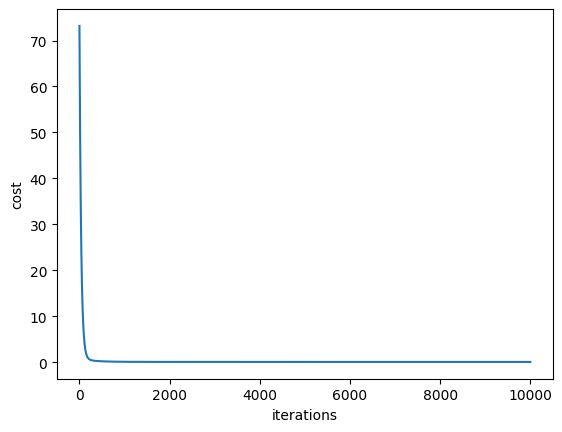

In [219]:
plt.plot(c)
plt.xlabel("iterations")
plt.ylabel("cost")
plt.show()